
# GPT-2 Symbols **Mini-Lab** — Student Edition

**Edit the parameters in the next cell (marked _EDIT HERE_) and run the cells in order.**
- PROMPT: your input text prompt
- TEMPERATURE: try 0.4 (conservative), 0.6 (balanced), 0.8 (exploratory)
- SIM_THRESHOLD: 0.50 merges more (coarser), 0.60 splits more (finer)


In [78]:

# === EDIT HERE ===
PROMPT = "Is the earth flat?"
MODEL = "gpt2"           # e.g., "gpt2", "distilgpt2"
TEMPERATURE = 0.75
TOP_K = 50
MAX_NEW_TOKENS = 300
SEED = 1

# Similarity (sentence -> symbol)
NGRAM_MIN = 3
NGRAM_MAX = 5
SIM_THRESHOLD = 0.45

# Optional: input your own text instead of generating
INPUT_TEXT = ""  # paste your own text here (leave empty to generate with GPT-2)


In [79]:

!pip -q install transformers==4.* torch scikit-learn matplotlib numpy


In [80]:
import re, math, json, numpy as np, matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from transformers import AutoTokenizer, AutoModelForCausalLM, set_seed

# Updated regex for splitting sentences, including handling of newline characters
SENT_REGEX = re.compile(r'(?<=[.!?])\s+|\n+')
ABBREV_END = re.compile(r'(?:^|\s)(?:Dr|Mr|Ms|Mrs|Prof|Sr|Jr|St|Mt|No)\.$')

def split_sentences(text: str):
    # Split by punctuation followed by space or by newline characters
    parts = re.split(SENT_REGEX, text)
    merged = []
    for seg in parts:
        s = seg.strip()
        if not s: continue
        # Check for abbreviations at the end of the *last* merged sentence
        if merged and ABBREV_END.search(merged[-1]):
            merged[-1] += " " + s
        else:
            merged.append(s)
    return merged

def tfidf_char_vectors(sentences, nmin=3, nmax=5):
    vec = TfidfVectorizer(analyzer="char", ngram_range=(nmin, nmax), min_df=1, norm="l2")
    X = vec.fit_transform(sentences).astype(np.float32)
    row_norms = np.sqrt((X.power(2)).sum(axis=1).A1) + 1e-9
    return X.multiply(1.0/row_norms[:,None]), vec

def greedy_cosine_clustering(Xn, sentences, sim_threshold=0.55):
    Xn_csr = Xn.tocsr() # Convert to CSR for efficient row slicing
    centroids = []; counts = []; exemplars = []; labels = []
    for i in range(Xn_csr.shape[0]):
        v = Xn_csr[i]
        if not centroids:
            centroids.append(v.copy()); counts.append(1); exemplars.append(sentences[i]); labels.append(0); continue
        sims = np.array([ (v.dot(c.T)).toarray()[0,0] for c in centroids ], dtype=np.float32)
        j = int(sims.argmax())
        if sims[j] >= sim_threshold:
            new_c = (centroids[j].multiply(counts[j]) + v).multiply(1.0/(counts[j]+1))
            denom = math.sqrt((new_c.power(2)).sum()) + 1e-12
            new_c = new_c.multiply(1.0/denom)
            centroids[j] = new_c; counts[j]+=1; labels.append(j)
        else:
            centroids.append(v.copy()); counts.append(1); exemplars.append(sentences[i]); labels.append(len(centroids)-1)
    return labels, centroids, exemplars

def int_labels_to_symbols(labels):
    if not labels: return "", []
    alphabet = [chr(ord('A') + i) for i in range(max(labels)+1)]
    sym = "".join(alphabet[i] for i in labels)
    return sym, alphabet

def run_length_encode(labels):
    if not labels: return []
    rle = []; cur = labels[0]; L = 1
    for x in labels[1:]:
        if x==cur: L+=1
        else: rle.append((cur,L)); cur=x; L=1
    rle.append((cur,L)); return rle

def classify_simple(labels):
    rle = run_length_encode(labels)
    if not rle:
        return {"class":"empty","switches":0,"mean_run":0.0,"majority_frac":0.0}
    total = sum(L for _,L in rle)
    switches = max(0, len(rle)-1)
    mean_run = total/len(rle)
    counts = {}
    for s,L in rle: counts[s] = counts.get(s,0)+L
    maj = max(counts, key=counts.get)
    majority_frac = counts[maj]/total
    if majority_frac>=0.60 and any(L>=4 for _,L in rle):
        label="fixed_attractor"
    elif switches>=6 and mean_run<=1.5:
        label="oscillatory"
    else:
        label="mixed"
    return {"class":label,"switches":switches,"mean_run":mean_run,"majority_frac":majority_frac}

def time_to_settle_index(labels, min_suffix=3):
    n=len(labels)
    if n==0: return None
    last=labels[-1]; r=1; i=n-2
    while i>=0 and labels[i]==last:
        r+=1; i-=1
    if r>=min_suffix:
        return i+1
    return None

def plot_barcode(labels, title="Symbol stream (sentences)"):
    if not labels:
        print("No labels to plot."); return
    K = max(labels)+1
    colors = plt.cm.tab20(np.linspace(0,1,max(3,K)))
    fig, ax = plt.subplots(figsize=(8,1.2))
    for i, lab in enumerate(labels):
        ax.axvspan(i, i+1, color=colors[lab % len(colors)], ec='none')
        ax.vlines(i+1, 0, 1, linewidth=0.5)
    ax.set_xlim(0, len(labels)); ax.set_ylim(0,1)
    ax.set_yticks([]); ax.set_xlabel("Sentence index"); ax.set_title(title)
    plt.tight_layout(); plt.show()

In [81]:

# --- Generate or use your own text ---
if INPUT_TEXT.strip():
    text = INPUT_TEXT
    print("=== Using your pasted INPUT_TEXT ===")
else:
    tok = AutoTokenizer.from_pretrained(MODEL)
    model = AutoModelForCausalLM.from_pretrained(MODEL); model.eval()
    set_seed(SEED)
    inputs = tok(PROMPT, return_tensors="pt")
    out_ids = model.generate(
        **inputs, do_sample=True, temperature=TEMPERATURE, top_k=TOP_K,
        max_new_tokens=MAX_NEW_TOKENS, eos_token_id=tok.eos_token_id
    )
    text = tok.decode(out_ids[0], skip_special_tokens=True)
    print("=== Generated text (first 800 chars) ===")
    print(text[:800])


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


=== Generated text (first 800 chars) ===
Is the earth flat?

In the first place, the earth is flat.

(This is a bit of an odd statement, as it is often not known that the earth is flat.)

The second thing you need to know is the earth is flat.

You may or may not be aware of it, but you may be curious about it. It's a very good thing.

It is not a physical phenomenon, and it's just because of its small size and its location in the sky.

The Earth is flat, though, because the earth doesn't move.

The Earth is Flat is a myth.

It is not a fact.

When you think about it, it is a myth. The Earth is not flat.

That is, the earth is not flat.

When you think about it, it is a myth.

The Earth is Flat is a myth.

The Earth is Flat is a myth.

The Earth is Flat is a myth.

The Earth is Flat is a myth.

The Earth is Flat is a myth.

The E


In [82]:
# --- Sentences -> symbols ---
sentences = split_sentences(text)
print("Number of sentences:", len(sentences))
for i, s in enumerate(sentences[:30]):
    print(f"[{i:02d}] {s}")
if len(sentences) > 30: print("... (truncated)")

Xn,_ = tfidf_char_vectors(sentences, NGRAM_MIN, NGRAM_MAX)
labels, cents, exemplars = greedy_cosine_clustering(Xn, sentences, sim_threshold=SIM_THRESHOLD)
symbol_stream, alphabet = int_labels_to_symbols(labels)

print("\n=== Symbol stream ===")
print(symbol_stream)

print("\nLegend (letter -> example sentence):")
seen=set()
for i, lab in enumerate(labels):
    if lab not in seen:
        print(f"  {alphabet[lab]}: {sentences[i]}"); seen.add(lab)

Number of sentences: 26
[00] Is the earth flat?
[01] In the first place, the earth is flat.
[02] (This is a bit of an odd statement, as it is often not known that the earth is flat.)
[03] The second thing you need to know is the earth is flat.
[04] You may or may not be aware of it, but you may be curious about it.
[05] It's a very good thing.
[06] It is not a physical phenomenon, and it's just because of its small size and its location in the sky.
[07] The Earth is flat, though, because the earth doesn't move.
[08] The Earth is Flat is a myth.
[09] It is not a fact.
[10] When you think about it, it is a myth.
[11] The Earth is not flat.
[12] That is, the earth is not flat.
[13] When you think about it, it is a myth.
[14] The Earth is Flat is a myth.
[15] The Earth is Flat is a myth.
[16] The Earth is Flat is a myth.
[17] The Earth is Flat is a myth.
[18] The Earth is Flat is a myth.
[19] The Earth is Flat is a myth.
[20] The Earth is Flat is a myth.
[21] The Earth is Flat is a myth.
[


=== Simple dynamics summary ===
{
  "class": "mixed",
  "switches": 13,
  "mean_run": 1.8571428571428572,
  "majority_frac": 0.5
}
Time to settle (first index after which all remaining sentences are the same symbol, suffix >= 3): 14


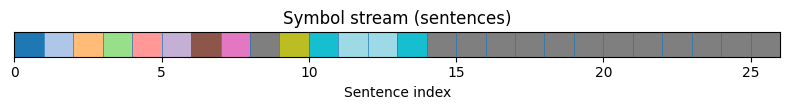


=== YOU CAN TRY THESE ===
1) Edit PROMPT, TEMPERATURE, SIM_THRESHOLD in the first cell; re-run.
2) Explore time_to_settle (or 'did not settle').
3) Try a lower and a higher temperature; compare.
4) Other ideas.


In [83]:

# --- Simple dynamics + time to settle + barcode ---
info = classify_simple(labels)
print("\n=== Simple dynamics summary ===")
import json
print(json.dumps(info, indent=2))

t_settle = time_to_settle_index(labels, min_suffix=3)
if t_settle is not None:
    print(f"Time to settle (first index after which all remaining sentences are the same symbol, suffix >= 3): {t_settle}")
else:
    print("Time to settle: did not settle (suffix >= 3).")

plot_barcode(labels, title="Symbol stream (sentences)")

print("\n=== YOU CAN TRY THESE ===")
print("1) Edit PROMPT, TEMPERATURE, SIM_THRESHOLD in the first cell; re-run.")
print("2) Explore time_to_settle (or 'did not settle').")
print("3) Try a lower and a higher temperature; compare.")
print("4) Other ideas.")
